# Notebook 04: Final Model Comparison and Evaluation

## Purpose

This is the final comparison notebook for the CA2 forecasting project. It loads the saved test predictions from Notebook 02 and Notebook 03, aligns all models on the same MSFT test dates, recomputes metrics in dollar space, and exports final report assets.

Models compared:

- Naive last-close baseline
- LSTM
- GRU
- PatchTST

## Link to the project workflow

This notebook is the Evaluation stage of the workflow. Earlier notebooks handled data preparation and modelling. Here the focus is model comparison, interpretation, limitations, and saved outputs that could support future reporting or deployment work.


## Setup and saved artifact paths

This cell imports the libraries used for comparison and defines the output paths. Notebook 04 intentionally consumes saved CSV outputs from earlier notebooks instead of retraining models.


In [1]:
from pathlib import Path
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Notebook 04 must consume saved prediction CSVs only.
# These paths are intentionally relative to the notebooks/ directory.
TABLE_DIR = Path('../outputs/tables')
PLOT_DIR = Path('../outputs/plots')
REPORT_ASSET_DIR = Path('../report_assets')

RNN_PRED_PATH = TABLE_DIR / 'rnn_test_predictions.csv'
PATCHTST_PRED_PATH = TABLE_DIR / 'patchtst_test_predictions.csv'
FINAL_METRICS_PATH = TABLE_DIR / 'final_metrics_comparison.csv'
FINAL_PREDICTIONS_PATH = TABLE_DIR / 'final_aligned_test_predictions.csv'

PLOT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_ASSET_DIR.mkdir(parents=True, exist_ok=True)

print('Comparison notebook setup complete.')

Comparison notebook setup complete.


## Load saved model predictions

The RNN prediction file should contain `Naive`, `LSTM`, and `GRU` forecasts. The PatchTST prediction file should contain `Naive` and `PatchTST` forecasts. Both files must include the same actual Close values and previous Close values so the comparison is fair.


In [2]:
required_files = [RNN_PRED_PATH, PATCHTST_PRED_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError('Required prediction CSV missing: ' + ', '.join(missing_files))

rnn_df = pd.read_csv(RNN_PRED_PATH, parse_dates=['ds'])
patchtst_df = pd.read_csv(PATCHTST_PRED_PATH, parse_dates=['ds'])

required_rnn_cols = {'ds', 'Actual', 'Previous_Close', 'Naive', 'LSTM', 'GRU'}
required_patchtst_cols = {'ds', 'Actual', 'Previous_Close', 'Naive', 'PatchTST'}

missing_rnn_cols = sorted(required_rnn_cols - set(rnn_df.columns))
missing_patchtst_cols = sorted(required_patchtst_cols - set(patchtst_df.columns))
if missing_rnn_cols:
    raise ValueError(f'RNN prediction CSV missing columns: {missing_rnn_cols}')
if missing_patchtst_cols:
    raise ValueError(f'PatchTST prediction CSV missing columns: {missing_patchtst_cols}')

print(f'Loaded RNN predictions: {rnn_df.shape[0]} rows')
print(f'Loaded PatchTST predictions: {patchtst_df.shape[0]} rows')
print(f'RNN date range: {rnn_df["ds"].min().date()} to {rnn_df["ds"].max().date()}')
print(f'PatchTST date range: {patchtst_df["ds"].min().date()} to {patchtst_df["ds"].max().date()}')

Loaded RNN predictions: 616 rows
Loaded PatchTST predictions: 616 rows
RNN date range: 2023-11-07 to 2026-04-23
PatchTST date range: 2023-11-07 to 2026-04-23


### Loaded prediction interpretation

The printed row counts and date ranges are a quick check that both modelling notebooks produced predictions for the expected test period before the final merge is attempted.


## Align predictions on the same test dates

The predictions are merged on `ds` so every model is evaluated on exactly the same trading days. The checks confirm the expected test length, date range, chronological order, uniqueness, and matching actual/naive values across the RNN and PatchTST files.


In [3]:
rnn_keep = rnn_df[['ds', 'Actual', 'Previous_Close', 'Naive', 'LSTM', 'GRU']].copy()
patch_keep = patchtst_df[['ds', 'Actual', 'Previous_Close', 'Naive', 'PatchTST']].copy()

merged = rnn_keep.merge(
    patch_keep,
    on='ds',
    how='inner',
    suffixes=('_RNN', '_PatchTST'),
)
merged = merged.sort_values('ds').reset_index(drop=True)

expected_rows = 616
expected_first_date = pd.Timestamp('2023-11-07')
expected_last_date = pd.Timestamp('2026-04-23')

checks = {
    'exactly 616 rows': len(merged) == expected_rows,
    'first date is 2023-11-07': merged['ds'].iloc[0] == expected_first_date,
    'last date is 2026-04-23': merged['ds'].iloc[-1] == expected_last_date,
    'ds parsed as datetime': pd.api.types.is_datetime64_any_dtype(merged['ds']),
    'dates sorted ascending': merged['ds'].is_monotonic_increasing,
    'dates unique': merged['ds'].is_unique,
}

for label, passed in checks.items():
    if not passed:
        raise AssertionError(f'Validation failed: {label}')

for col_pair in [('Actual_RNN', 'Actual_PatchTST'), ('Previous_Close_RNN', 'Previous_Close_PatchTST'), ('Naive_RNN', 'Naive_PatchTST')]:
    left, right = col_pair
    max_diff = float(np.max(np.abs(merged[left] - merged[right])))
    if not np.allclose(merged[left], merged[right], rtol=1e-7, atol=1e-3):
        raise AssertionError(f'{left} and {right} are not numerically close; max abs diff={max_diff:.6f}')
    print(f'{left} matches {right}; max abs diff={max_diff:.6f}')

final_predictions = pd.DataFrame({
    'ds': merged['ds'],
    'Actual': merged['Actual_RNN'],
    'Previous_Close': merged['Previous_Close_RNN'],
    'Naive': merged['Naive_RNN'],
    'LSTM': merged['LSTM'],
    'GRU': merged['GRU'],
    'PatchTST': merged['PatchTST'],
})

required_final_cols = ['Actual', 'Previous_Close', 'Naive', 'LSTM', 'GRU', 'PatchTST']
if final_predictions[required_final_cols].isna().any().any():
    missing_summary = final_predictions[required_final_cols].isna().sum()
    raise AssertionError(f'Missing values found in final predictions: {missing_summary.to_dict()}')

final_predictions.to_csv(FINAL_PREDICTIONS_PATH, index=False)

print(f'Final aligned prediction table saved to {FINAL_PREDICTIONS_PATH}')
print(f'Final aligned rows: {len(final_predictions)}')
print(f'Final aligned date range: {final_predictions["ds"].min().date()} to {final_predictions["ds"].max().date()}')

Actual_RNN matches Actual_PatchTST; max abs diff=0.000148
Previous_Close_RNN matches Previous_Close_PatchTST; max abs diff=0.000148
Naive_RNN matches Naive_PatchTST; max abs diff=0.000148
Final aligned prediction table saved to ../outputs/tables/final_aligned_test_predictions.csv
Final aligned rows: 616
Final aligned date range: 2023-11-07 to 2026-04-23


### Alignment interpretation

After this step, `final_predictions` is the single test table used for comparison. Each row contains the same actual Close value and one prediction from each model, which prevents unfair metric differences caused by mismatched dates.


## Final evaluation metrics

All metrics are recomputed after inverse transformation, so the errors are in the original dollar price scale. This is easier to interpret than scaled-space loss values.

Metric meanings:

- `RMSE`: typical error size in USD, with larger errors penalised more strongly
- `MAE`: average absolute error in USD
- `MAPE`: average percentage error relative to the actual price
- `R2`: how much variance is explained compared with a mean-style prediction
- `Directional_Accuracy`: how often the model predicts the correct up/down move relative to the previous Close

For one-step stock-price levels, the naive last-close baseline is important because it is often very hard to beat.


In [4]:
def directional_accuracy(actual, previous_close, prediction):
    actual_direction = np.sign(actual - previous_close)
    predicted_direction = np.sign(prediction - previous_close)
    return float(np.mean(actual_direction == predicted_direction) * 100)

def calculate_metrics(df, model_name):
    actual = df['Actual'].to_numpy(dtype=float)
    prediction = df[model_name].to_numpy(dtype=float)
    previous_close = df['Previous_Close'].to_numpy(dtype=float)

    mse = mean_squared_error(actual, prediction)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, prediction)
    mape = np.mean(np.abs((actual - prediction) / actual)) * 100
    r2 = r2_score(actual, prediction)

    if model_name == 'Naive':
        direction = np.nan
    else:
        direction = directional_accuracy(actual, previous_close, prediction)

    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2,
        'Directional_Accuracy': direction,
    }

models = ['Naive', 'LSTM', 'GRU', 'PatchTST']
metrics_df = pd.DataFrame([calculate_metrics(final_predictions, model) for model in models])
metrics_df = metrics_df.sort_values('RMSE').reset_index(drop=True)
metrics_df.to_csv(FINAL_METRICS_PATH, index=False)

expected_rmse = {
    'Naive': 6.29,
    'LSTM': 92.50,
    'GRU': 34.58,
    'PatchTST': 6.36,
}

for model, expected in expected_rmse.items():
    actual_rmse = float(metrics_df.loc[metrics_df['Model'] == model, 'RMSE'].iloc[0])
    tolerance = max(2.0, expected * 0.10)
    if abs(actual_rmse - expected) > tolerance:
        warnings.warn(
            f'{model} RMSE differs strongly from expected value. '
            f'Expected around {expected:.2f}, got {actual_rmse:.2f}. '
            'This usually indicates an alignment, artifact, or rounding issue.'
        )

print(f'Final metrics saved to {FINAL_METRICS_PATH}')
display(metrics_df)

Final metrics saved to ../outputs/tables/final_metrics_comparison.csv


,Model,MSE,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,Naive,39.6082,6.2935,4.3907,1.0333,0.9813,NaN
1,PatchTST,40.4714,6.3617,4.5088,1.0610,0.9809,47.5649
2,GRU,1195.5981,34.5774,30.7473,6.8891,0.4348,47.4026
3,LSTM,8556.4068,92.5008,86.7691,19.6100,-3.0450,46.9156


### Metric interpretation

In the saved results, the naive baseline has the lowest RMSE. PatchTST is very close to the naive baseline and is the strongest deep learning model by RMSE, MAE, and MAPE. GRU performs better than LSTM among the recurrent models.

Directional accuracy for the deep learning models is below 50% in the saved output, so the forecasts should not be treated as reliable up/down trading signals.


## Forecast and residual plots

The full test plot shows overall tracking across the test period. The 30-day zoom makes short-term behaviour easier to inspect. The residual plots show prediction error over time, where values above zero mean over-prediction and values below zero mean under-prediction.


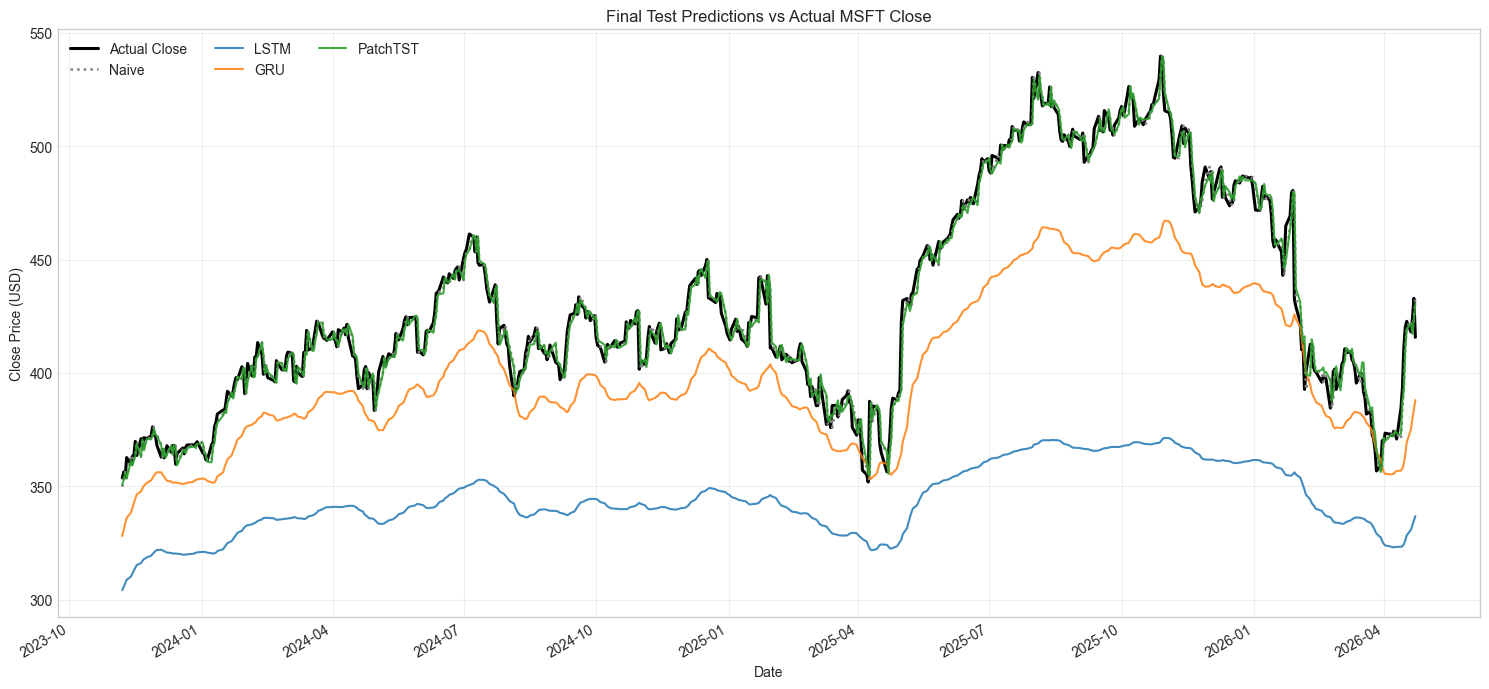

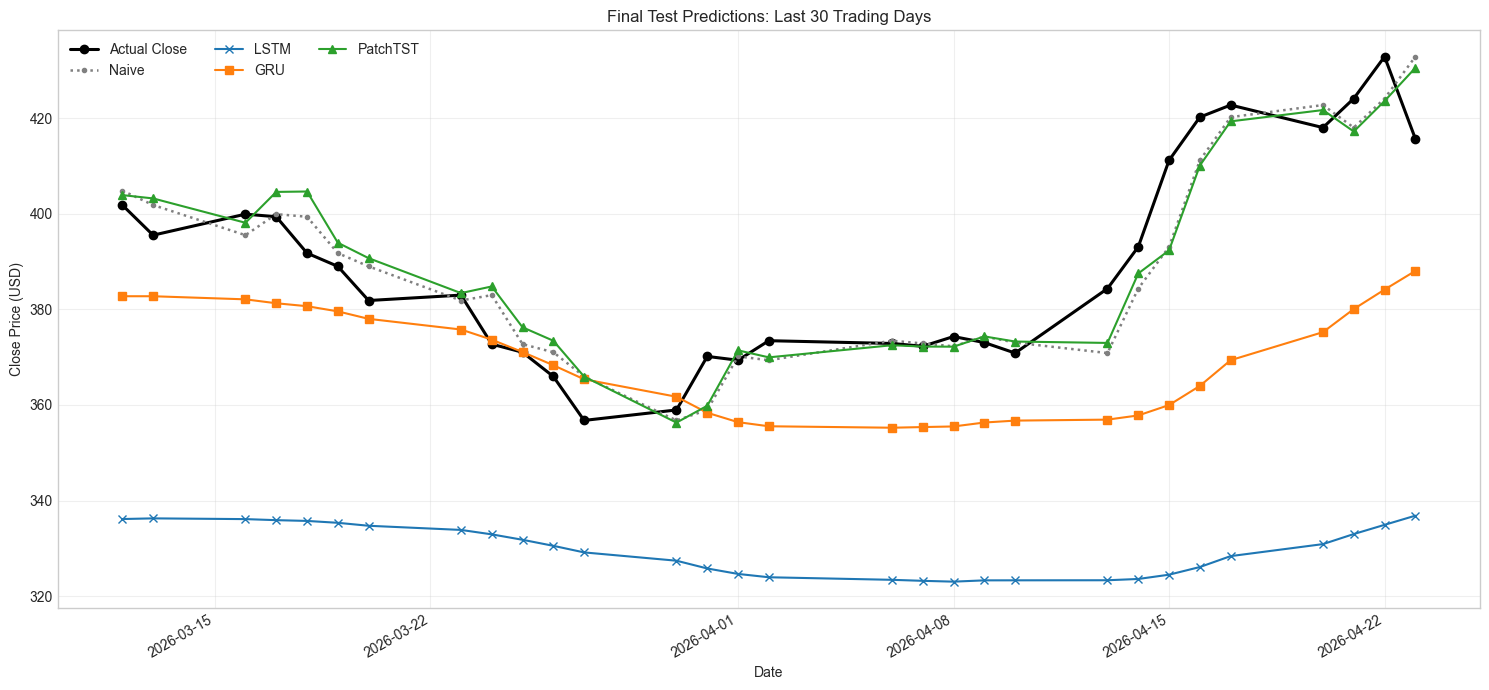

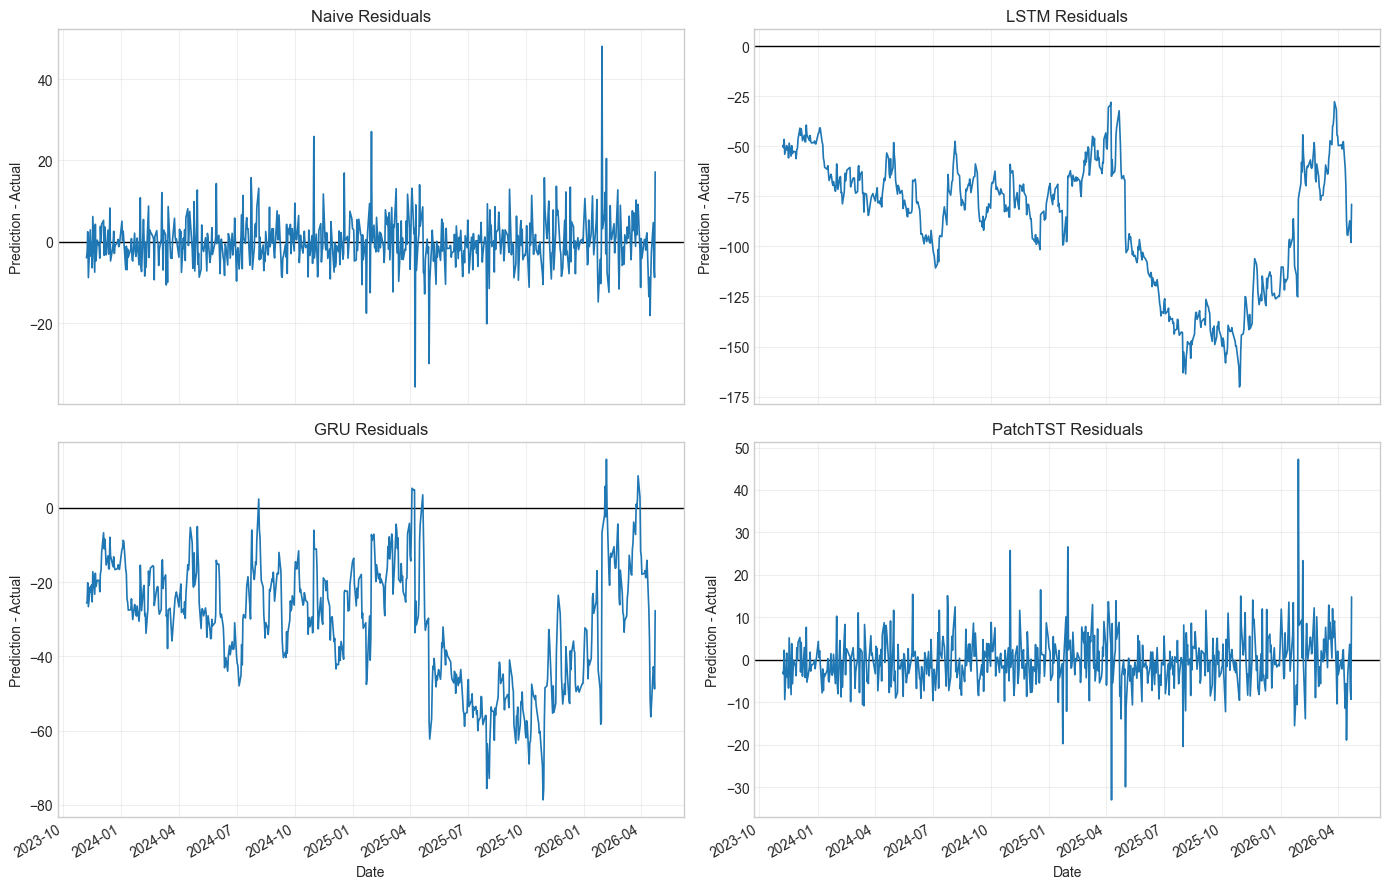

Saved final plots:
- ../outputs/plots/test_predictions_all.png
- ../outputs/plots/zoomed_30d_predictions.png
- ../outputs/plots/final_residuals_comparison.png


In [5]:
plot_df = final_predictions.copy()

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(plot_df['ds'], plot_df['Actual'], label='Actual Close', color='black', linewidth=2.2)
ax.plot(plot_df['ds'], plot_df['Naive'], label='Naive', color='gray', linestyle=':', linewidth=1.8)
ax.plot(plot_df['ds'], plot_df['LSTM'], label='LSTM', alpha=0.85)
ax.plot(plot_df['ds'], plot_df['GRU'], label='GRU', alpha=0.85)
ax.plot(plot_df['ds'], plot_df['PatchTST'], label='PatchTST', alpha=0.9)
ax.set_title('Final Test Predictions vs Actual MSFT Close')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
all_plot_path = PLOT_DIR / 'test_predictions_all.png'
fig.savefig(all_plot_path, dpi=150, bbox_inches='tight')
plt.show()

zoom_df = plot_df.tail(30)
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(zoom_df['ds'], zoom_df['Actual'], label='Actual Close', color='black', linewidth=2.2, marker='o')
ax.plot(zoom_df['ds'], zoom_df['Naive'], label='Naive', color='gray', linestyle=':', linewidth=1.8, marker='.')
ax.plot(zoom_df['ds'], zoom_df['LSTM'], label='LSTM', marker='x')
ax.plot(zoom_df['ds'], zoom_df['GRU'], label='GRU', marker='s')
ax.plot(zoom_df['ds'], zoom_df['PatchTST'], label='PatchTST', marker='^')
ax.set_title('Final Test Predictions: Last 30 Trading Days')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
zoom_plot_path = PLOT_DIR / 'zoomed_30d_predictions.png'
fig.savefig(zoom_plot_path, dpi=150, bbox_inches='tight')
plt.show()

residual_df = plot_df[['ds', 'Actual']].copy()
for model in models:
    residual_df[model] = plot_df[model] - plot_df['Actual']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()
for ax, model in zip(axes, models):
    ax.axhline(0, color='black', linewidth=1)
    ax.plot(residual_df['ds'], residual_df[model], linewidth=1.2)
    ax.set_title(f'{model} Residuals')
    ax.set_ylabel('Prediction - Actual')
    ax.grid(True, alpha=0.3)
for ax in axes[-2:]:
    ax.set_xlabel('Date')
fig.autofmt_xdate()
fig.tight_layout()
residual_plot_path = PLOT_DIR / 'final_residuals_comparison.png'
fig.savefig(residual_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print('Saved final plots:')
print(f'- {all_plot_path}')
print(f'- {zoom_plot_path}')
print(f'- {residual_plot_path}')

### Plot interpretation

If a forecast line follows the actual line but reacts late, that suggests lag rather than genuine predictive power. The residual panels are especially useful for seeing whether a model has persistent bias during the later test period.


## Report assets

The final tables and plots are copied into `report_assets` so the CA2 report can refer to one clean location. Missing optional assets are skipped rather than stopping the notebook.


In [6]:
assets_to_copy = [
    FINAL_METRICS_PATH,
    FINAL_PREDICTIONS_PATH,
    PLOT_DIR / 'test_predictions_all.png',
    PLOT_DIR / 'zoomed_30d_predictions.png',
    PLOT_DIR / 'final_residuals_comparison.png',
    TABLE_DIR / 'rnn_metrics.csv',
    TABLE_DIR / 'patchtst_metrics.csv',
    TABLE_DIR / 'rnn_tuning_results.csv',
    PLOT_DIR / 'lstm_learning_curves.png',
    PLOT_DIR / 'gru_learning_curves.png',
    PLOT_DIR / 'patchtst_test_predictions.png',
]

for asset in assets_to_copy:
    if asset.exists():
        destination = REPORT_ASSET_DIR / asset.name
        shutil.copy2(asset, destination)
        print(f'Copied {asset} -> {destination}')
    else:
        print(f'Skipped missing optional asset: {asset}')

Copied ../outputs/tables/final_metrics_comparison.csv -> ../report_assets/final_metrics_comparison.csv
Copied ../outputs/tables/final_aligned_test_predictions.csv -> ../report_assets/final_aligned_test_predictions.csv
Copied ../outputs/plots/test_predictions_all.png -> ../report_assets/test_predictions_all.png
Copied ../outputs/plots/zoomed_30d_predictions.png -> ../report_assets/zoomed_30d_predictions.png
Copied ../outputs/plots/final_residuals_comparison.png -> ../report_assets/final_residuals_comparison.png
Copied ../outputs/tables/rnn_metrics.csv -> ../report_assets/rnn_metrics.csv
Copied ../outputs/tables/patchtst_metrics.csv -> ../report_assets/patchtst_metrics.csv
Copied ../outputs/tables/rnn_tuning_results.csv -> ../report_assets/rnn_tuning_results.csv
Copied ../outputs/plots/lstm_learning_curves.png -> ../report_assets/lstm_learning_curves.png
Copied ../outputs/plots/gru_learning_curves.png -> ../report_assets/gru_learning_curves.png
Copied ../outputs/plots/patchtst_test_predi

## Final interpretation

The final comparison shows that the naive last-close baseline is the strongest model by RMSE on the saved test predictions. This should be reported directly because it is a realistic and difficult benchmark for one-step-ahead stock-price level forecasting.

PatchTST is the strongest deep learning model in the saved results and performs much closer to the naive baseline than LSTM or GRU. GRU is the better recurrent model because it clearly improves on LSTM, although both recurrent models struggle on the later test period.

Main limitations:

- Stock prices are noisy and affected by information not present in OHLCV history.
- The series is non-stationary, so later price levels and market behaviour differ from the training period.
- Price-level models can appear to track the curve while still lagging behind real moves.
- Directional accuracy is weak, so these forecasts are not a trading system.
- PatchTST used the Close-only fallback in the saved run, so it is not perfectly feature-equivalent to the OHLCV LSTM/GRU inputs.


In [7]:
print('Notebook 04 completed successfully')
print(f'final row count: {len(final_predictions)}')
print(f'final date range: {final_predictions["ds"].min().date()} to {final_predictions["ds"].max().date()}')
print('confirmation: all models are aligned on the same 616 test dates')
print('final metrics table:')
print(metrics_df.to_string(index=False))

Notebook 04 completed successfully
final row count: 616
final date range: 2023-11-07 to 2026-04-23
confirmation: all models are aligned on the same 616 test dates
final metrics table:
   Model       MSE    RMSE     MAE    MAPE      R2  Directional_Accuracy
   Naive   39.6082  6.2935  4.3907  1.0333  0.9813                   NaN
PatchTST   40.4714  6.3617  4.5088  1.0610  0.9809               47.5649
     GRU 1195.5981 34.5774 30.7473  6.8891  0.4348               47.4026
    LSTM 8556.4068 92.5008 86.7691 19.6100 -3.0450               46.9156


## Final conclusion

For this CA2 project, the best test RMSE comes from the naive last-close baseline. Among the deep learning models, PatchTST gives the strongest overall test performance, followed by GRU and then LSTM.

The main conclusion is not that deep learning cannot be used for forecasting, but that one-step-ahead stock-price levels are difficult to beat with direct price models. The saved metrics, plots, and residuals support this conclusion and provide the final evidence for the report.
